# Oscillations in Gene Regulation: The Repressilator

## From bistability to oscillations

In module B we saw that **two** mutually repressing proteins create bistability.
Now consider **three** proteins, each repressing the next one in a cycle:

$$A \dashv B \dashv C \dashv A$$

The system can no longer settle at either "A wins" or "B wins" — the repression keeps
rotating. With sufficient cooperativity the symmetric fixed point becomes unstable and
the network **oscillates indefinitely**: a biochemical clock built from nothing but
cyclic negative feedback.

Elowitz & Leibler demonstrated this in 2000 by constructing the circuit synthetically
in *E. coli* using three repressor proteins — LacI, TetR and λ cI — and measuring
fluorescent oscillations in individual bacteria (Elowitz & Leibler, *Nature* 403, 335–338, 2000).
Their key message: **oscillations are a property of circuit topology, not special chemistry**.


## The Model

### Full 6-variable model (mRNAs + proteins)

Each gene has an mRNA $m_i$ and a protein $p_i$.  The protein of gene 3 represses gene 1,
gene 1 represses gene 2, and gene 2 represses gene 3:

$$\frac{dm_i}{dt} = -m_i + \frac{\alpha}{1 + p_{i-1}^n} + \alpha_0$$

$$\frac{dp_i}{dt} = -\beta\,(p_i - m_i)$$

| Parameter | Meaning |
|---|---|
| $\alpha$ | maximal transcription rate |
| $\alpha_0$ | basal (leaky) transcription |
| $n$ | Hill coefficient — cooperativity of repression |
| $\beta$ | ratio of protein to mRNA degradation rates |

Index convention: repressor of gene 1 is protein 3 ($p_3$), of gene 2 is $p_1$, of gene 3 is $p_2$.

### Reduced 3-variable model (proteins only)

Assuming mRNAs equilibrate fast ($dm_i/dt \approx 0$, quasi-steady state $m_i \approx \alpha/(1+p_{i-1}^n) + \alpha_0$):

$$\frac{dp_i}{dt} = \frac{\alpha}{1 + p_{i-1}^n} + \alpha_0 - p_i$$

This is simpler and exposes the circuit logic directly.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
from ipywidgets import interact, FloatSlider, IntSlider

%matplotlib inline

## Full Model: Time Series

We use the parameters from Elowitz & Leibler (2000) in dimensionless form.


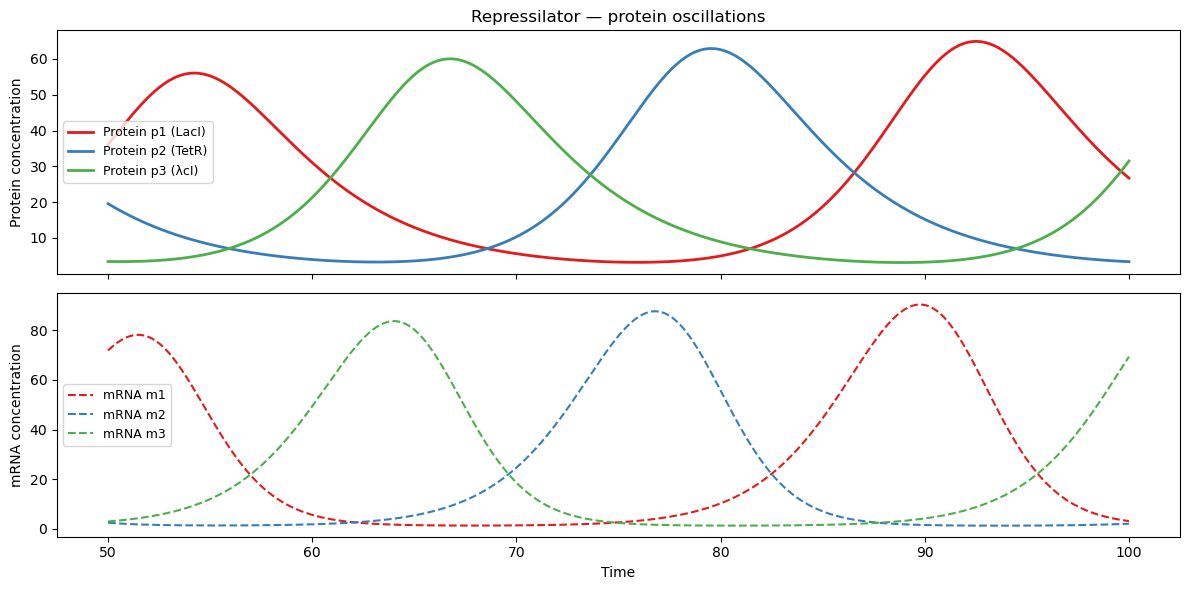

In [2]:
def repressilator_6var(t, y, alpha, alpha0, n, beta):
    """
    Full 6-variable repressilator: mRNAs m1,m2,m3 and proteins p1,p2,p3.
    Repression cycle:  p3 -| gene1,  p1 -| gene2,  p2 -| gene3
    """
    m1, p1, m2, p2, m3, p3 = y
    dm1 = -m1 + alpha / (1 + p3**n) + alpha0
    dp1 = -beta * (p1 - m1)
    dm2 = -m2 + alpha / (1 + p1**n) + alpha0
    dp2 = -beta * (p2 - m2)
    dm3 = -m3 + alpha / (1 + p2**n) + alpha0
    dp3 = -beta * (p3 - m3)
    return [dm1, dp1, dm2, dp2, dm3, dp3]

# Elowitz & Leibler (2000) dimensionless parameters
alpha  = 1000   # strong transcription: necessary for clear oscillations
alpha0 = 1      # small basal leakage
n      = 2      # dimer repressors — n=2 is enough with the mRNA dynamics
beta   = 0.2    # slow protein degradation relative to mRNA

y0  = [0, 2, 0, 1, 0, 3]    # asymmetric start to break symmetry
sol = solve_ivp(repressilator_6var, (0, 400), y0,
                args=(alpha, alpha0, n, beta),
                method='LSODA', max_step=0.05, dense_output=True)

# Discard transient and evaluate on a uniform grid
t_plot = np.linspace(50, 100, 5000)
y_plot = sol.sol(t_plot)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

colors = ['#e41a1c', '#377eb8', '#4daf4a']
labels_p = ['Protein p1 (LacI)',  'Protein p2 (TetR)',  'Protein p3 (λcI)']
labels_m = ['mRNA m1', 'mRNA m2', 'mRNA m3']

for i in range(3):
    axes[0].plot(t_plot, y_plot[2*i+1], color=colors[i], linewidth=2, label=labels_p[i])
    axes[1].plot(t_plot, y_plot[2*i],   color=colors[i], linewidth=1.5,
                 linestyle='dashed', label=labels_m[i])

# Measure period
peaks, _ = find_peaks(y_plot[1], prominence=50)
if len(peaks) > 1:
    period = np.mean(np.diff(t_plot[peaks]))
    axes[0].set_title(f'Repressilator — protein oscillations   (period ≈ {period:.1f})')
else:
    axes[0].set_title('Repressilator — protein oscillations')

axes[0].set_ylabel('Protein concentration'); axes[0].legend(fontsize=9)
axes[1].set_ylabel('mRNA concentration');    axes[1].legend(fontsize=9)
axes[1].set_xlabel('Time')
plt.tight_layout();

The three proteins oscillate with equal amplitude and a **120° phase shift** between them
— the clock ticks through all three states in sequence.
The mRNA oscillations are nearly in phase with their protein (fast mRNA dynamics),
but the protein lags slightly because of the finite $\beta$.

## State Space: The Limit Cycle

In the three-protein state space the asymptotic oscillation traces a closed loop — a **limit cycle**.
All trajectories from different initial conditions converge onto the same loop.


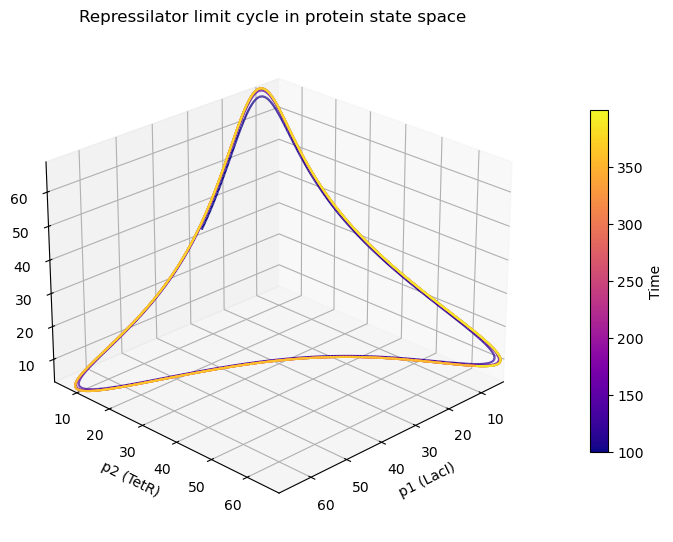

In [3]:
# Longer run for clean limit cycle
t_lc  = np.linspace(100, 400, 8000)
y_lc  = sol.sol(t_lc)
p1_lc, p2_lc, p3_lc = y_lc[1], y_lc[3], y_lc[5]

fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')

# Colour by time (shows rotation direction)
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection

points  = np.array([p1_lc, p2_lc, p3_lc]).T.reshape(-1, 1, 3)
segs    = np.concatenate([points[:-1], points[1:]], axis=1)
coll    = Line3DCollection(segs, cmap='plasma', linewidth=1.5)
coll.set_array(t_lc[:-1])
ax.add_collection(coll)

ax.set_xlim(p1_lc.min(), p1_lc.max())
ax.set_ylim(p2_lc.min(), p2_lc.max())
ax.set_zlim(p3_lc.min(), p3_lc.max())
ax.set_xlabel('p1 (LacI)'); ax.set_ylabel('p2 (TetR)'); ax.set_zlabel('p3 (λcI)')
ax.set_title('Repressilator limit cycle in protein state space')
ax.view_init(elev=25, azim=45)
plt.colorbar(coll, ax=ax, label='Time', shrink=0.6, pad=0.1)
plt.tight_layout();

## Reduced 3-Variable Model

Setting mRNA to quasi-steady state simplifies the system to three equations.
This version requires higher cooperativity ($n \geq 3$) to oscillate, because the
destabilising mRNA time delay is absent — the repression is instantaneous.

The reduced model is useful for exploring the parameter space quickly.


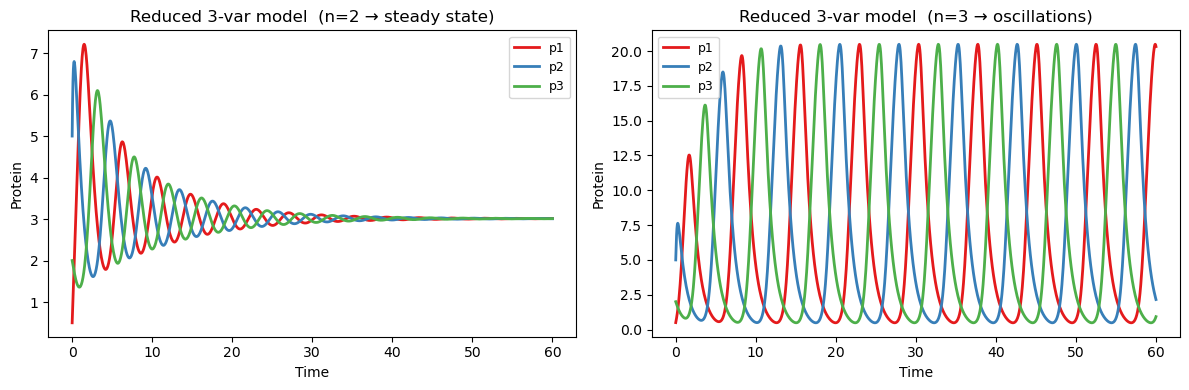

In [4]:
def repressilator_3var(t, y, alpha, alpha0, n):
    """
    Reduced protein-only repressilator (quasi-steady-state mRNA assumption).
    Oscillates for n >= 3; steady state for n=1,2 without mRNA dynamics.
    """
    p1, p2, p3 = y
    dp1 = alpha / (1 + p3**n) + alpha0 - p1
    dp2 = alpha / (1 + p1**n) + alpha0 - p2
    dp3 = alpha / (1 + p2**n) + alpha0 - p3
    return [dp1, dp2, dp3]

# Compare n = 2 (steady state) vs n = 3 (oscillations)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for n_val, ax, title_sfx in [(2, axes[0], 'n=2 → steady state'), 
                              (3, axes[1], 'n=3 → oscillations')]:
    sol_r = solve_ivp(repressilator_3var, (0, 60), [0.5, 5.0, 2.0],
                      args=(30, 0.03, n_val), max_step=0.05)
    for i, col, lbl in zip([0,1,2], colors, ['p1','p2','p3']):
        ax.plot(sol_r.t, sol_r.y[i], color=col, linewidth=2, label=lbl)
    ax.set_title(f'Reduced 3-var model  ({title_sfx})')
    ax.set_xlabel('Time'); ax.set_ylabel('Protein')
    ax.legend(fontsize=9)

plt.tight_layout();

The contrast is stark: with $n=2$ the system decays to a single steady state;
with $n=3$ it oscillates indefinitely. **Cooperativity is the switch that turns a ring
of repressors from a point attractor into a clock.**

Why does the full 6-variable model oscillate at $n=2$ while the reduced model needs $n=3$?
The mRNA dynamics introduce a **time delay** between transcription and effective repression.
This delay provides the extra destabilisation that lower cooperativity cannot.

## Interactive Exploration

Explore how $\alpha$ (transcription strength) and $n$ (cooperativity) control the oscillation.


In [11]:
def plot_repressilator(alpha_val=100, n_val=3, model='reduced'):
    plt.close('all')

    if model == 'reduced':
        # 3-var: period ~7-12 time units; integrate to 90, show from t=30 (~5-8 cycles)
        t_end, t_show = 90, 30
        sol_i = solve_ivp(repressilator_3var, (0, t_end), [0.5, 5.0, 2.0],
                          args=(alpha_val, 0.03, n_val),
                          method='LSODA', max_step=0.05, dense_output=True)
        idx_p = [0, 1, 2]
    else:
        # 6-var: period ~30 time units; integrate to 250, show from t=100 (~5 cycles)
        # Note: n=2 needs alpha >= 40 to oscillate; n=3 oscillates from alpha ~10
        t_end, t_show = 250, 100
        sol_i = solve_ivp(repressilator_6var, (0, t_end), [0, 2, 0, 1, 0, 3],
                          args=(alpha_val, 1.0, n_val, 0.2),
                          method='LSODA', max_step=0.05, dense_output=True)
        idx_p = [1, 3, 5]

    t_i = np.linspace(t_show, t_end, 3000)
    y_i = sol_i.sol(t_i)

    amp = max(y_i[idx_p[0]].max() - y_i[idx_p[0]].min(), 0.01)
    peaks_i, _ = find_peaks(y_i[idx_p[0]], prominence=amp * 0.3)
    period_str = (f'period ≈ {np.mean(np.diff(t_i[peaks_i])):.1f}'
                  if len(peaks_i) > 1 else 'no oscillation')

    fig, ax = plt.subplots(figsize=(10, 4))
    for i, col, lbl in zip(idx_p, colors, ['p1', 'p2', 'p3']):
        ax.plot(t_i, y_i[i], color=col, linewidth=2, label=lbl)
    ax.set_xlabel('Time'); ax.set_ylabel('Protein')
    ax.set_title(f'{model} model  |  α={alpha_val}, n={n_val}  |  {period_str}')
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

from ipywidgets import Dropdown
interact(plot_repressilator,
         alpha_val = FloatSlider(min=5, max=200, step=5, value=100,
                                 description='α', continuous_update=False),
         n_val     = IntSlider(min=1, max=5, step=1, value=3,
                               description='n', continuous_update=False),
         model     = Dropdown(options=['reduced', 'full 6-var'], value='reduced',
                              description='model'));

interactive(children=(FloatSlider(value=30.0, continuous_update=False, description='α', max=200.0, min=5.0, st…

## Summary

The repressilator shows that **oscillations are a topological phenomenon**:

- A ring of three mutually repressing genes oscillates by cyclic frustration — no state is stable.
- The oscillation requires **cooperativity** ($n > 1$) and sufficient transcription strength ($\alpha$).
- The full model (with mRNA dynamics) oscillates at lower cooperativity than the reduced model,
  because mRNA introduces a time delay that aids destabilisation.
- All trajectories converge onto the same **limit cycle** in state space — a stable rhythm.

**Comparison with module C's enzyme oscillator**: the topology is identical (negative feedback
in a closed loop). The repressilator uses three genetic components; the enzyme oscillator
achieves the same behaviour with two metabolic variables by combining forward inhibition and
product feedback in a single reaction. The dynamical mechanism is the same.

**Connection to module D**: once you have an oscillator, coupling many of them in space through
diffusion can produce travelling waves — the subject of the next module.

**Noise and cell-to-cell variability**: Elowitz & Leibler also measured gene expression fluctuations
using a second fluorescent reporter, finding large stochastic variability between individual cells.
In a population of repressilator cells, these fluctuations cause **phase diffusion**: cells started
at identical conditions gradually drift out of synchrony with one another. Correcting for this —
without a cell-communication mechanism such as quorum sensing — remains an open challenge in
synthetic biology, and a direct motivation for studying coupled oscillator networks.
